In [1]:
import os
import pickle
import sys
sys.path.append("/data1/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import torch
import pandas as pd
import gzip
import networkx as nx
import seaborn as sns
from collections import Counter
import itertools
import matplotlib.pyplot as plt
from metient.util import plotting_util as putil
from metient.util import data_extraction_util as dutil
from metient.util.globals import *

output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"

metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")


In [2]:
import numpy.core.numeric
# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones))

total_seeded_sites = 0
total_polyclonally_seeded_sites = 0
        
for clone in clones:
    print("\nClone", clone)
    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
    V = pckl[OUT_LABElING_KEY][0]
    A = dutil.adjacency_matrix_from_parents(pckl[OUT_PARENTS_KEY][0])
    G = putil.migration_graph(V, A).cpu()
    
    col_sums = G.sum(dim=0) 
    total_seeded_sites += (col_sums >= 1).sum().item()
    total_polyclonally_seeded_sites += (col_sums > 1).sum().item()

print("Total seeded sites across all clones:", total_seeded_sites)
print("Total polyclonally seeded sites across all clones:", total_polyclonally_seeded_sites)
print("Proportion of polyclonally seeded sites:", total_polyclonally_seeded_sites / total_seeded_sites)

100

Clone 1


/tmp/ipykernel_3531121/6233767.py:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pckl = pickle.load(f)
/data1/morrisq/divyak/conda_envs/met3/lib/python3.14/site-packages/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]



Clone 2

Clone 3

Clone 4

Clone 5

Clone 6

Clone 7

Clone 8

Clone 9

Clone 10

Clone 11

Clone 12

Clone 13

Clone 14

Clone 15

Clone 16

Clone 17

Clone 18

Clone 19

Clone 20

Clone 21

Clone 22

Clone 23

Clone 24

Clone 25

Clone 26

Clone 27

Clone 28

Clone 29

Clone 30

Clone 31

Clone 32

Clone 33

Clone 34

Clone 35

Clone 36

Clone 37

Clone 38

Clone 39

Clone 40

Clone 41

Clone 42

Clone 43

Clone 44

Clone 45

Clone 46

Clone 47

Clone 48

Clone 49

Clone 50

Clone 51

Clone 52

Clone 53

Clone 54

Clone 55

Clone 56

Clone 57

Clone 58

Clone 59

Clone 60

Clone 61

Clone 62

Clone 63

Clone 64

Clone 65

Clone 66

Clone 67

Clone 68

Clone 69

Clone 70

Clone 71

Clone 72

Clone 73

Clone 74

Clone 75

Clone 76

Clone 77

Clone 78

Clone 79

Clone 80

Clone 81

Clone 82

Clone 83

Clone 84

Clone 85

Clone 86

Clone 87

Clone 88

Clone 89

Clone 90

Clone 91

Clone 92

Clone 93

Clone 94

Clone 95

Clone 96

Clone 97

Clone 98

Clone 99

Clone 100
Total seeded site

In [3]:
clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones))

data = {
    "clone": [],
    "probability": [],
    "mig_pattern": [],
}

for clone in clones:
    print("\nClone", clone)
    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
    losses = pckl[OUT_LOSSES_KEY]
    probs = putil.losses_to_probabilities(losses)
    _, _, _, mig_graphs = lt.extract_info(metient_results_dir, clone)
    for mig_graph,prob in zip(mig_graphs, probs):
        G = (mig_graph.fill_diagonal_(0) >= 1).float()
        non_zero_indices = G.nonzero()
        non_zero_indices_list = []
        for pair in non_zero_indices:
            non_zero_indices_list.append((int(pair[0]), int(pair[1])))
        data['clone'].append(clone)
        data['probability'].append(prob)
        data['mig_pattern'].append(tuple(non_zero_indices_list))

df = pd.DataFrame(data)
df


100

Clone 1


/tmp/ipykernel_3531121/837511007.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pckl = pickle.load(f)



Clone 2

Clone 3

Clone 4

Clone 5

Clone 6

Clone 7

Clone 8

Clone 9

Clone 10

Clone 11

Clone 12

Clone 13

Clone 14

Clone 15

Clone 16

Clone 17

Clone 18

Clone 19

Clone 20

Clone 21

Clone 22

Clone 23

Clone 24

Clone 25

Clone 26

Clone 27

Clone 28

Clone 29

Clone 30

Clone 31

Clone 32

Clone 33

Clone 34

Clone 35

Clone 36

Clone 37

Clone 38

Clone 39

Clone 40

Clone 41

Clone 42

Clone 43

Clone 44

Clone 45

Clone 46

Clone 47

Clone 48

Clone 49

Clone 50

Clone 51

Clone 52

Clone 53

Clone 54

Clone 55

Clone 56

Clone 57

Clone 58

Clone 59

Clone 60

Clone 61

Clone 62

Clone 63

Clone 64

Clone 65

Clone 66

Clone 67

Clone 68

Clone 69

Clone 70

Clone 71

Clone 72

Clone 73

Clone 74

Clone 75

Clone 76

Clone 77

Clone 78

Clone 79

Clone 80

Clone 81

Clone 82

Clone 83

Clone 84

Clone 85

Clone 86

Clone 87

Clone 88

Clone 89

Clone 90

Clone 91

Clone 92

Clone 93

Clone 94

Clone 95

Clone 96

Clone 97

Clone 98

Clone 99

Clone 100


,clone,probability,mig_pattern
0,1,0.199,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
1,1,0.039,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
2,1,0.038,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
3,1,0.037,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2..."
4,1,0.037,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2..."
...,...,...,...
1013,99,0.469,"((0, 4), (4, 1), (4, 2), (4, 3))"
1014,99,0.467,"((0, 1), (0, 2), (0, 3), (0, 4), (4, 2), (4, 3))"
1015,99,0.064,"((0, 1), (0, 2), (0, 3), (0, 4))"
1016,100,0.881,"((0, 3), (3, 1), (3, 2), (3, 4), (3, 5))"


In [4]:
# Count how many times each migration pattern appears for each clone
pattern_counts = df.groupby(['clone', 'mig_pattern']).size().reset_index(name='count')

# Filter to only show patterns that appear more than once for a clone
repeated_patterns = pattern_counts[pattern_counts['count'] > 1]

# Sort by clone and count
repeated_patterns = repeated_patterns.sort_values(['clone', 'count'], ascending=[True, False])

print("Migration patterns that appear multiple times for the same clone:")
print(repeated_patterns)


Migration patterns that appear multiple times for the same clone:
     clone                                        mig_pattern  count
1        1  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...      2
30       2  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...      3
27       2  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...      2
68       3  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (4, 0...      8
70       3  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (4, 0...      2
..     ...                                                ...    ...
729     90  ((0, 4), (2, 3), (2, 4), (3, 4), (3, 5), (4, 1...      2
735     91   ((0, 1), (1, 2), (1, 3), (1, 4), (3, 4), (4, 3))      3
738     91   ((0, 2), (2, 1), (2, 3), (2, 4), (3, 4), (4, 3))      3
736     91           ((0, 1), (1, 2), (1, 3), (1, 4), (4, 3))      2
739     91           ((0, 2), (2, 1), (2, 3), (2, 4), (4, 3))      2

[126 rows x 3 columns]


In [5]:
import ast

df['mig_pattern'] = df['mig_pattern'].apply(lambda x: str(x))

# Step 1: Group by clone and mig_pattern to calculate the weighted sum of probabilities
weighted_avg_df = (df.groupby(['clone', 'mig_pattern'])
                    .agg(weighted_probability=('probability', 'sum'))
                    .reset_index())

# Step 2: For each clone, find the mig_pattern with the highest weighted probability
consensus_pattern_df = (weighted_avg_df.loc[weighted_avg_df.groupby('clone')['weighted_probability'].idxmax()]
                        .rename(columns={'mig_pattern': 'consensus_mig_pattern'}))

# Step 3: Return DataFrame with clone and the consensus migration pattern
consensus_pattern_df =  consensus_pattern_df[['clone', 'consensus_mig_pattern', 'weighted_probability']]
consensus_pattern_df['consensus_mig_pattern'] = consensus_pattern_df['consensus_mig_pattern'].apply(ast.literal_eval)


def count_shared_subgraphs(graphs, max_subgraph_size=30):
    subgraph_counter = Counter()

    # Iterate over each graph in the list of graphs
    for G in graphs:
        # Get the set of edges in the current graph
        edges = set(G.edges())

        # Generate subgraphs of size from 2 to max_subgraph_size
        for size in range(1, 6):
            # Generate all combinations of edges of the given size
            for edge_comb in itertools.combinations(edges, size):
                # Sort the edge combination to ensure consistency in key
                subgraph_counter[tuple(sorted(edge_comb))] += 1

    return subgraph_counter

all_graphs = []

all_edges = list(consensus_pattern_df['consensus_mig_pattern'])
for edge_list in all_edges:
    edge_list = [(lt.TISSUE_ORDER[edge[0]],lt.TISSUE_ORDER[edge[1]]) for edge in edge_list]
    G = nx.DiGraph()
    G.add_edges_from(edge_list)
    all_graphs.append(G)

# Count shared subgraphs
subgraph_counts = count_shared_subgraphs(all_graphs)
sorted_subgraph_counts = dict(sorted(subgraph_counts.items(), key=lambda x: x[1], reverse=True))

In [6]:
consensus_pattern_df

,clone,consensus_mig_pattern,weighted_probability
1,1,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...",0.237
26,2,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...",0.139
68,3,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (4, 0...",0.386
106,4,"((0, 3), (0, 5), (1, 4), (2, 0), (2, 1), (2, 3...",0.127
125,5,"((0, 3), (0, 4), (2, 3), (2, 4), (3, 0), (3, 1...",0.212
...,...,...,...
755,96,"((0, 2),)",1.000
758,97,"((0, 4), (3, 1), (3, 2), (4, 3))",0.588
760,98,"((0, 4), (4, 1), (4, 2), (4, 3), (4, 5))",0.881
763,99,"((0, 4), (4, 1), (4, 2), (4, 3))",0.469


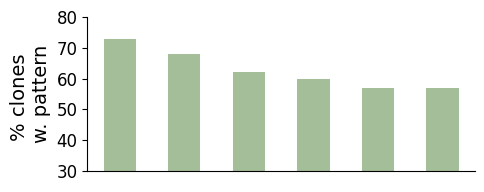

In [7]:

data = [[str(k),100*v/len(consensus_pattern_df)] for k,v in sorted_subgraph_counts.items()][:6]
sorted_subgraph_df = pd.DataFrame(data,columns=['Sequential pattern', '% clones \nw. pattern'])
sorted_subgraph_df
fig, ax = plt.subplots(figsize=(5, 2))  # Adjust the size as needed
sns.barplot(x="Sequential pattern", y="% clones \nw. pattern", data=sorted_subgraph_df, color='#a1c492')
for patch in ax.patches:
    current_width = patch.get_width()
    diff = current_width - 0.5  # target width
    # change width
    patch.set_width(0.5)
    # optionally re-center
    patch.set_x(patch.get_x() + diff / 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([])
plt.yticks(fontsize=12)

plt.ylim(30,80)
plt.ylabel('% clones \nw. pattern', fontsize=14)
plt.xlabel('')
plt.savefig(os.path.join(output_dir,f"sequential pattern.svg"), dpi=300, bbox_inches='tight',pad_inches=0.2)  # Save with tight bounding box

plt.show()
plt.close()